In [ ]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions


df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]


df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

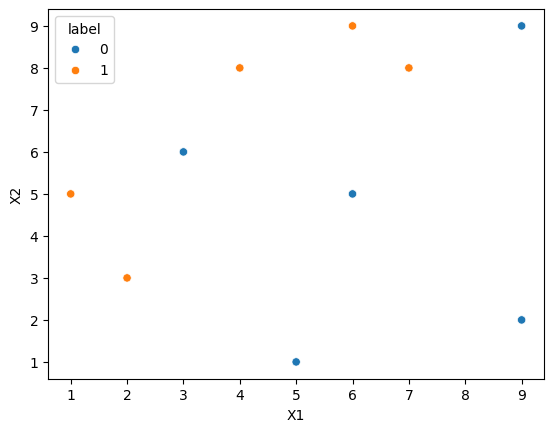

In [ ]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [ ]:
df['weights'] = 1/df.shape[0]

df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values


In [ ]:
# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

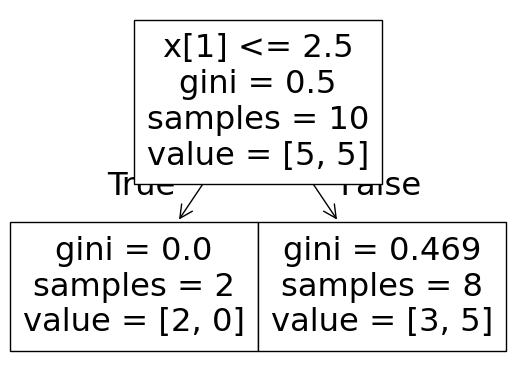

In [ ]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

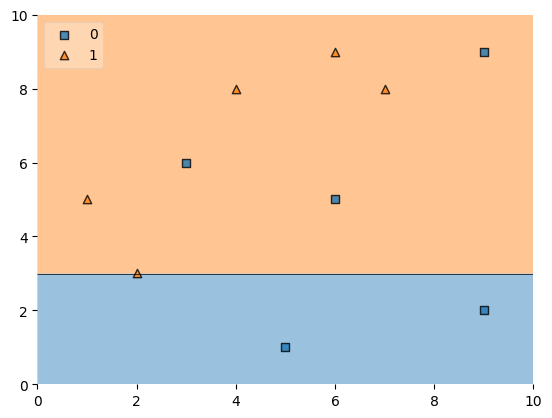

In [ ]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [ ]:
df['y_pred'] = dt1.predict(X)

df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [ ]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [ ]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [ ]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [ ]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [ ]:
df['updated_weights'].sum()
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [ ]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [ ]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [ ]:
df = df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

In [ ]:
df

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [ ]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [ ]:
index_values = create_new_dataset(df)

index_values

[9, 8, 9, 9, 6, 8, 0, 8, 2, 6]

In [ ]:
second_df = df.iloc[index_values,[0,1,2,3]]


second_df

,X1,X2,label,weights
9,9,2,0,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
8,9,9,0,0.1
0,1,5,1,0.1
8,9,9,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1


In [ ]:
dt2 = DecisionTreeClassifier(max_depth=1)


X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values


dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.0\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.625, 0.5, '  False')]

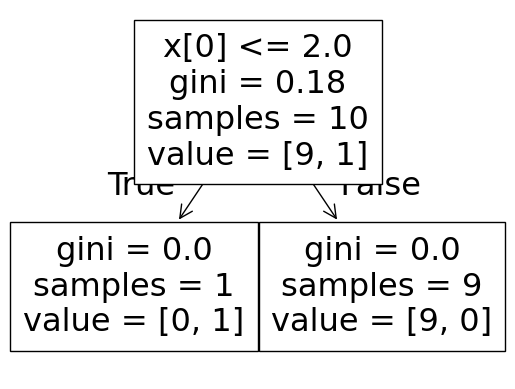

In [ ]:
plot_tree(dt2)

<Axes: >

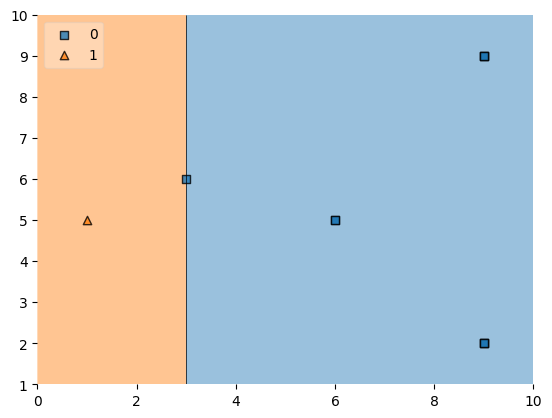

In [ ]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [ ]:
second_df['y_pred'] = dt2.predict(X)


second_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,0
0,1,5,1,0.1,1
8,9,9,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0


In [ ]:
alpha2 = calculate_model_weight(0.2)

alpha2

np.float64(0.6931471805599453)

In [ ]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.69):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)


In [ ]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [ ]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [ ]:
second_df['nomalized_weights'].sum()

np.float64(1.0)

In [ ]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])


second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [ ]:
second_df = second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

In [ ]:
second_df

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
9,9,2,0,0.1,0,0.1,0.0,0.1
8,9,9,0,0.1,0,0.1,0.1,0.2
9,9,2,0,0.1,0,0.1,0.2,0.3
9,9,2,0,0.1,0,0.1,0.3,0.4
6,6,5,0,0.1,0,0.1,0.4,0.5
8,9,9,0,0.1,0,0.1,0.5,0.6
0,1,5,1,0.1,1,0.1,0.6,0.7
8,9,9,0,0.1,0,0.1,0.7,0.8
2,3,6,0,0.1,0,0.1,0.8,0.9
6,6,5,0,0.1,0,0.1,0.9,1.0


In [ ]:
index_values = create_new_dataset(second_df)


third_df = second_df.iloc[index_values,[0,1,2,3]]


third_df

,X1,X2,label,weights
6,6,5,0,0.1
9,9,2,0,0.1
0,1,5,1,0.1
6,6,5,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
0,1,5,1,0.1


In [ ]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

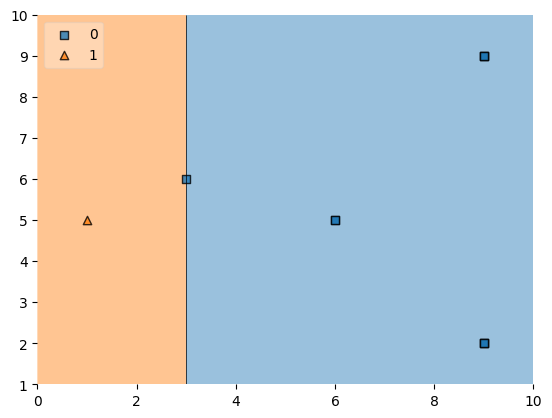

In [ ]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [ ]:
third_df['y_pred'] = dt3.predict(X)

third_df

,X1,X2,label,weights,y_pred
6,6,5,0,0.1,0
9,9,2,0,0.1,0
0,1,5,1,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,1
6,6,5,0,0.1,0
6,6,5,0,0.1,0
0,1,5,1,0.1,0


In [ ]:
alpha3 = calculate_model_weight(0.6)
alpha3

np.float64(-0.20273255405408214)

In [ ]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 0.6931471805599453 -0.20273255405408214


Prediction

In [ ]:
query = np.array([1,5]).reshape(1,2)
print(dt1.predict(query),
dt2.predict(query),
dt3.predict(query))

[1] [1] [1]


In [ ]:
alpha1 * dt1.predict(query) + alpha2 * dt2.predict(query) + alpha3 * dt3.predict(query)

array([0.91406356])

In [ ]:
np.sign(0.4236)

np.float64(1.0)

In [ ]:
query = np.array([9,9]).reshape(1,2)

In [ ]:
alpha1 * dt1.predict(query) + alpha2 * dt2.predict(query) + alpha3 * dt3.predict(query)

array([0.42364893])

Gradient boost step by step

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [ ]:
import pandas as pd

df = pd.DataFrame()

df['X'] = X.reshape(100)
df['y'] = y


df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs Y')

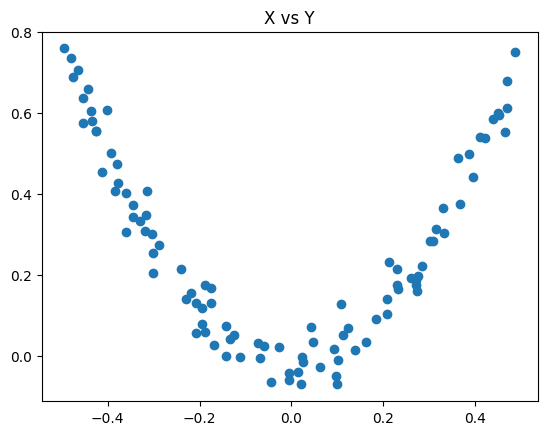

In [ ]:
plt.scatter(df['X'],df['y'])
plt.title('X vs Y')

In [ ]:
df['pred1'] = df['y'].mean()
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [ ]:
df['res1']= df['y']-df['pred1']

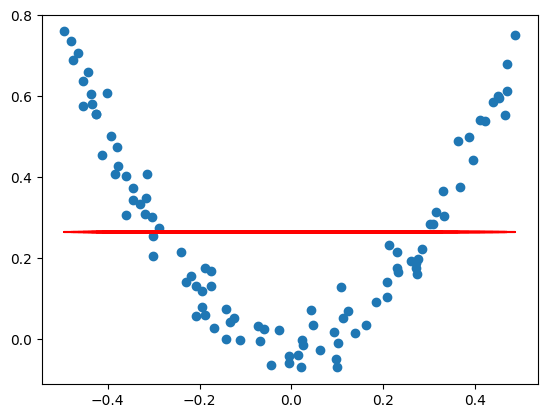

In [ ]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

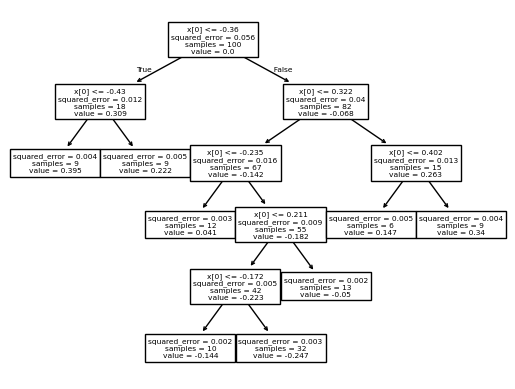

In [ ]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [ ]:
# generating X_test
X_test = np.linspace(-0.5, 0.5, 500)

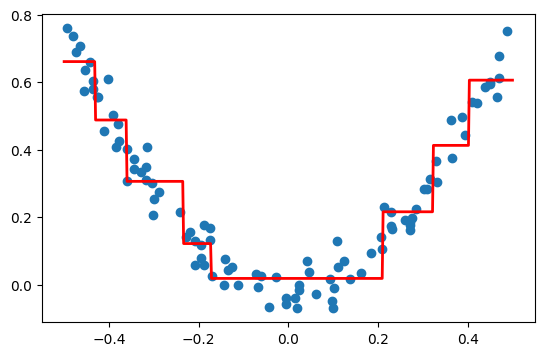

In [ ]:
y_pred = 0.265458 + tree1.predict(X_test.reshape(500, 1))

plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [ ]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [ ]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [ ]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])

Text(0.5, 1.0, 'X vs y')

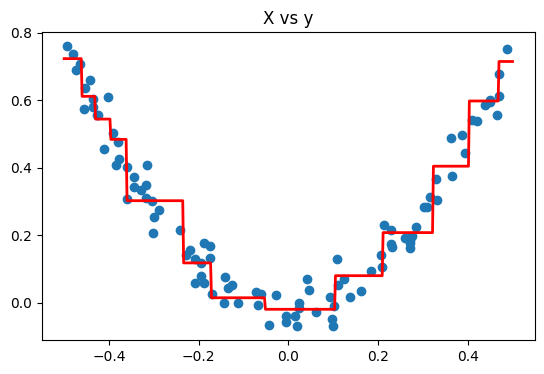

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [ ]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


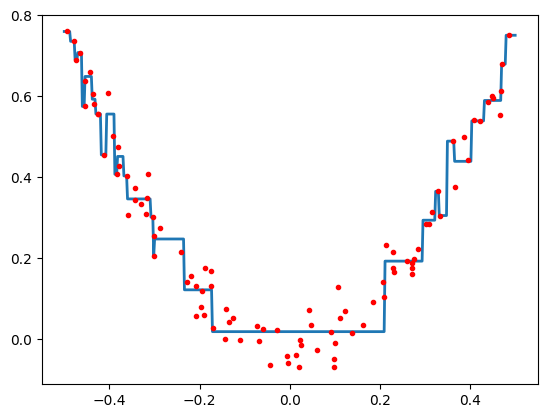

4


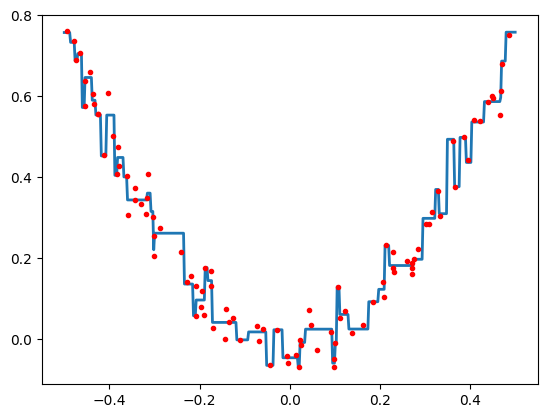

3


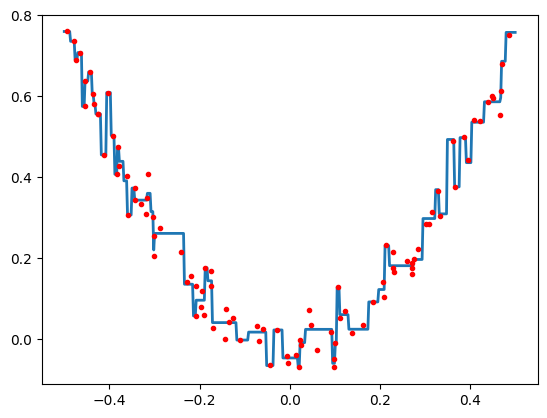

2


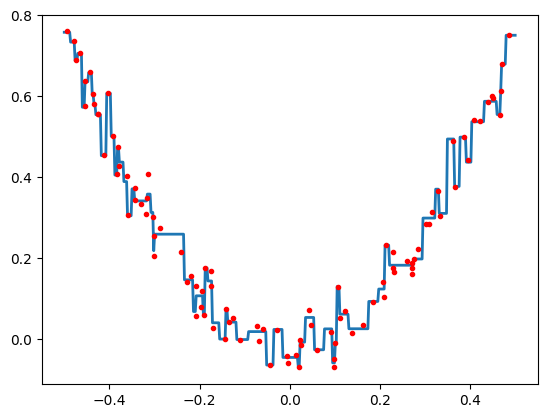

1


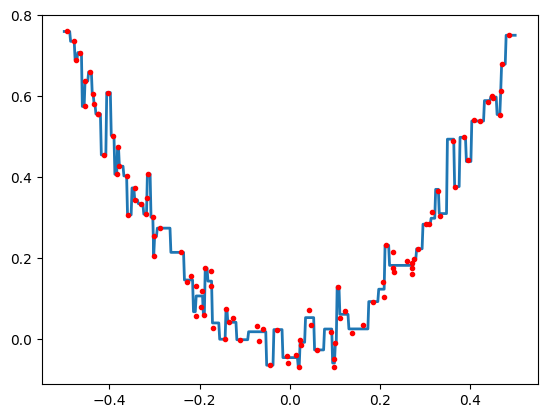

In [ ]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)